In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

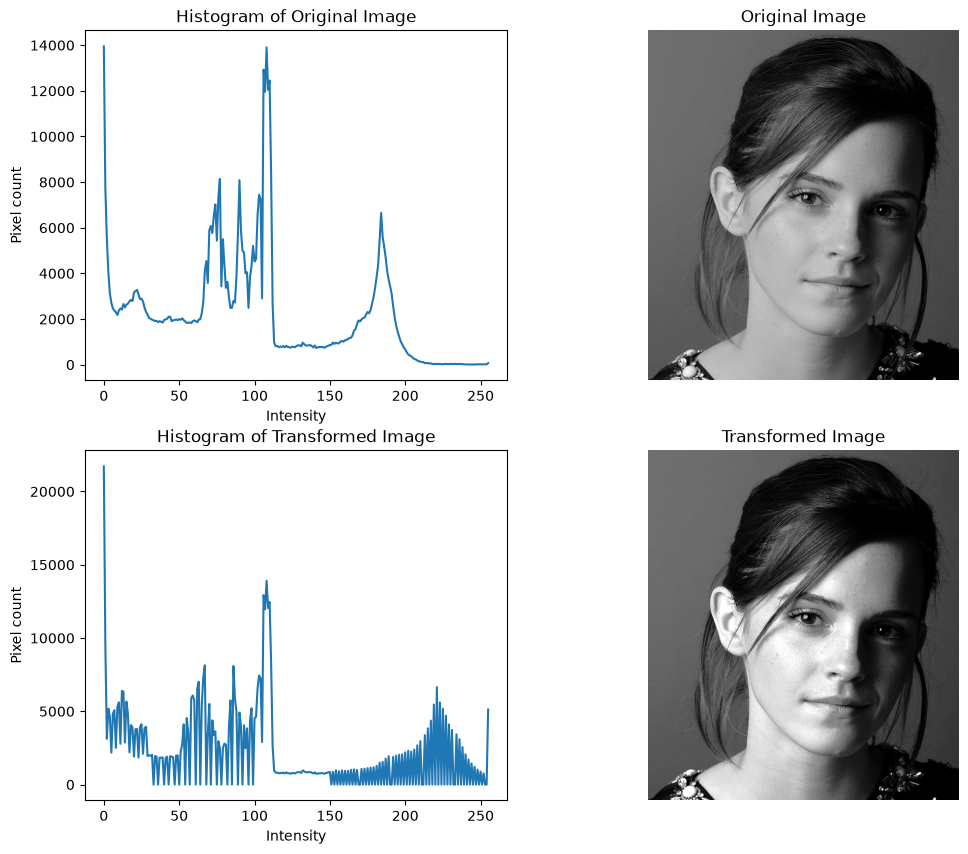

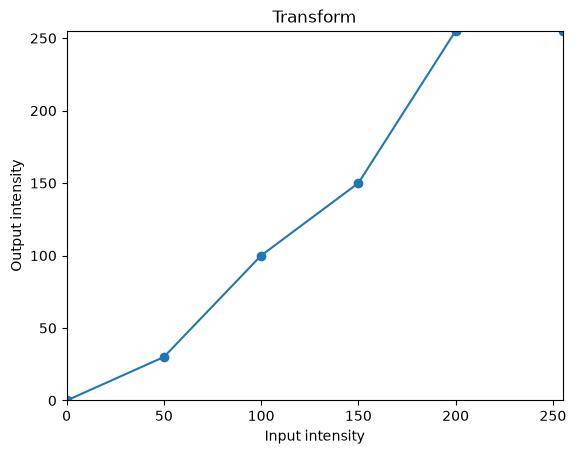

In [2]:
im = cv.imread("images/q1.jpeg", cv.IMREAD_GRAYSCALE)

hist = cv.calcHist([im], [0], None, [256], [0,256])

xp = [0, 50, 100, 150, 200, 255]
fp = [0, 30, 100, 150, 255, 255]

lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)

transformed_image = cv.LUT(im, lut)
tr_hist = cv.calcHist([transformed_image], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im, cmap='gray')
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(tr_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Transformed Image")

axes[1][1].imshow(transformed_image, cmap='gray')
axes[1][1].axis('off')
axes[1][1].set_title("Transformed Image")

plt.show()

plt.plot(xp, fp, 'o-')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transform")

plt.show()

Text(0.5, 1.0, 'Gray Matter Image')

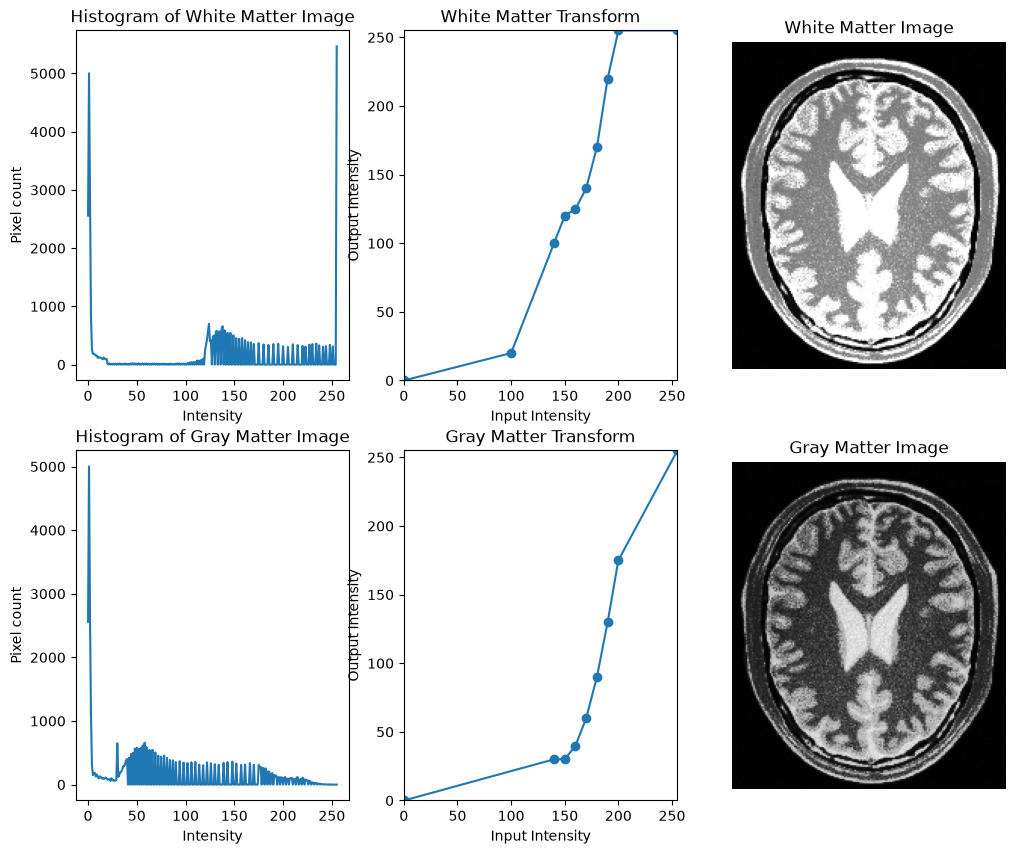

In [28]:
im = cv.imread("images/q2.jpeg")

hist = cv.calcHist([im], [0], None, [256], [0,256])

xp_wm = [0, 100, 140, 150, 160, 170, 180, 190, 200, 255]
fp_wm = [0,  20, 100, 120, 125, 140, 170, 220, 255, 255]

xp_gm = [0, 140, 150, 160, 170, 180, 190, 200, 255]
fp_gm = [0,  30,  30,  40,  60,  90, 130, 175, 255]

lut_wm = np.interp(np.arange(256), xp_wm, fp_wm).astype(np.uint8)
lut_gm = np.interp(np.arange(256), xp_gm, fp_gm).astype(np.uint8)

transformed_image_wm = cv.LUT(im, lut_wm)
wm_hist = cv.calcHist([transformed_image_wm], [0], None, [256], [0,256])

transformed_image_gm = cv.LUT(im, lut_gm)
gm_hist = cv.calcHist([transformed_image_gm], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 3, figsize=(12, 10))

axes[0][0].plot(wm_hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of White Matter Image")

axes[0][1].plot(xp_wm, fp_wm, 'o-')
axes[0][1].set_xlim(0,255)
axes[0][1].set_ylim(0,255)
axes[0][1].set_xlabel("Input Intensity")
axes[0][1].set_ylabel("Output Intensity")
axes[0][1].set_title("White Matter Transform")

axes[0][2].imshow(transformed_image_wm, cmap='gray')
axes[0][2].axis('off')
axes[0][2].set_title("White Matter Image")

axes[1][0].plot(gm_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Gray Matter Image")

axes[1][1].plot(xp_gm, fp_gm, 'o-')
axes[1][1].set_xlim(0,255)
axes[1][1].set_ylim(0,255)
axes[1][1].set_xlabel("Input Intensity")
axes[1][1].set_ylabel("Output Intensity")
axes[1][1].set_title("Gray Matter Transform")

axes[1][2].imshow(transformed_image_gm, cmap='gray')
axes[1][2].axis('off')
axes[1][2].set_title("Gray Matter Image")



Text(0.5, 1.0, 'Corrected Image')

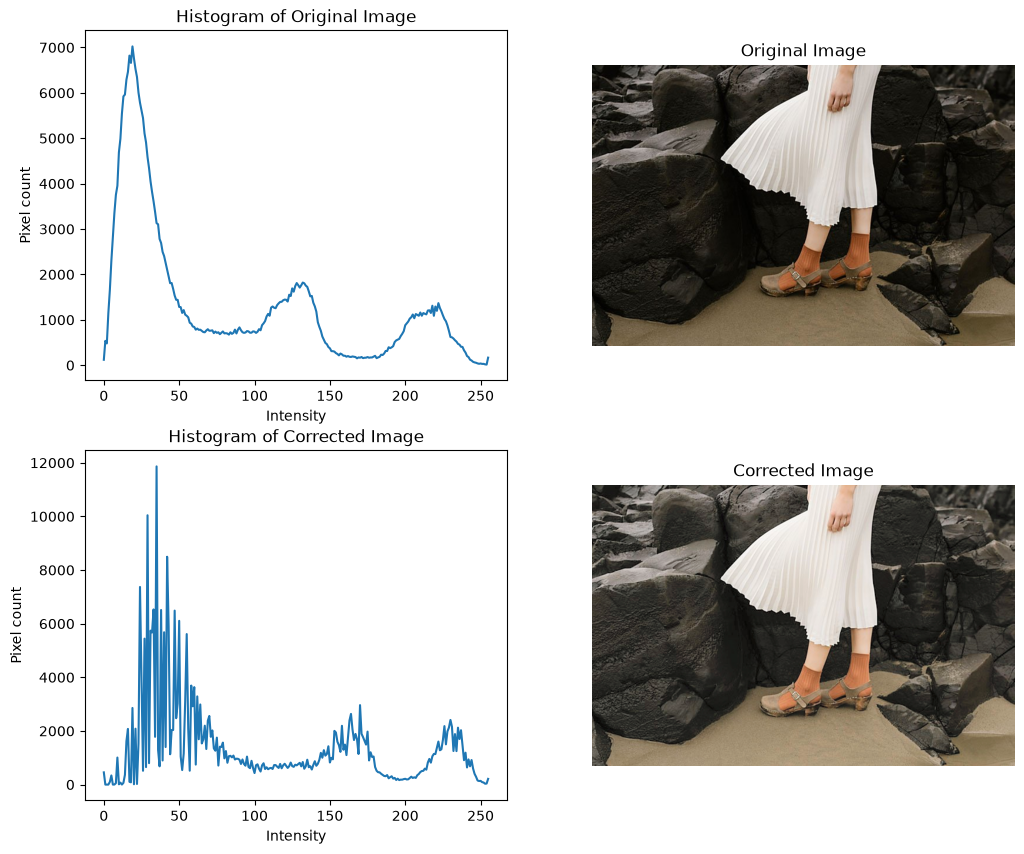

In [46]:
def gamma_correct(im, gamma):
    lut = np.array([((i/255.0)**gamma)*255 for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(im, lut)

gamma = 0.65

im = cv.imread("images/q3.jpeg")
im_lab = cv.cvtColor(im, cv.COLOR_BGR2LAB)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
hist = cv.calcHist([im_rgb], [0], None, [256], [0,256])

l_channel, a_channel, b_channel = cv.split(im_lab)

gamma_corrected_l = gamma_correct(l_channel, gamma)

reconstructed_im_lab = cv.merge([gamma_corrected_l, a_channel, b_channel])
reconstructed_im_rgb = cv.cvtColor(reconstructed_im_lab, cv.COLOR_LAB2RGB)
gamma_hist = cv.calcHist([reconstructed_im_rgb], [0], None, [256], [0,256])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0][0].plot(hist)
axes[0][0].set_xlabel("Intensity")
axes[0][0].set_ylabel("Pixel count")
axes[0][0].set_title("Histogram of Original Image")

axes[0][1].imshow(im_rgb)
axes[0][1].axis('off')
axes[0][1].set_title("Original Image")

axes[1][0].plot(gamma_hist)
axes[1][0].set_xlabel("Intensity")
axes[1][0].set_ylabel("Pixel count")
axes[1][0].set_title("Histogram of Corrected Image")

axes[1][1].imshow(reconstructed_im_rgb)
axes[1][1].axis('off')
axes[1][1].set_title("Corrected Image")

Text(0.5, 1.0, 'Vibrance Transformed Image')

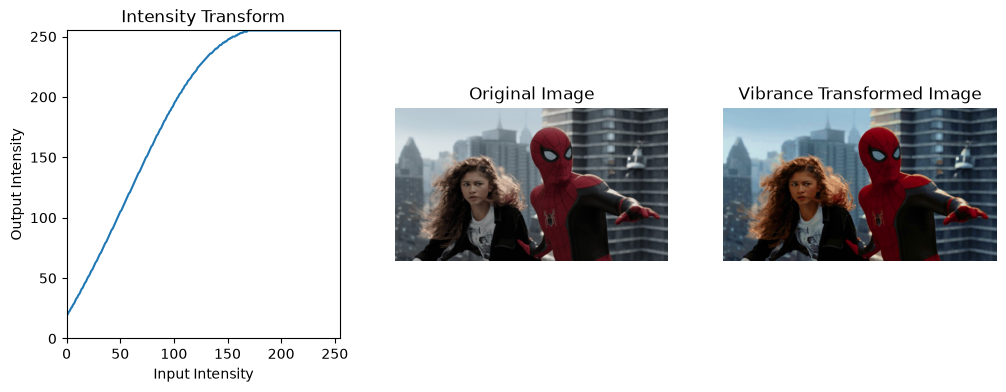

In [54]:
def vibrance_transform(i, a, sigma):
    f_inter = i + a*128*np.exp(-(i-128)**2/(2*sigma**2))
    f = min(f_inter, 255)
    return f

im = cv.imread("images/q4.jpeg")
im_hsv = cv.cvtColor(im, cv.COLOR_BGR2HSV)
hue, saturation, value = cv.split(im_hsv)

a = 0.8
sigma = 70

lut = np.array([vibrance_transform(i, a, sigma) for i in np.arange(0, 256)]).astype("uint8")
im_sat_tform = cv.LUT(saturation, lut)

vibr_hsv = cv.merge([hue, im_sat_tform, value])

im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
vibr_rgb = cv.cvtColor(vibr_hsv, cv.COLOR_HSV2RGB) 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(np.arange(256), lut)
axes[0].set_xlim(0,255)
axes[0].set_ylim(0,255)
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_title("Intensity Transform")

axes[1].imshow(im_rgb)
axes[1].axis('off')
axes[1].set_title("Original Image")

axes[2].imshow(vibr_rgb)
axes[2].axis('off')
axes[2].set_title("Vibrance Transformed Image")


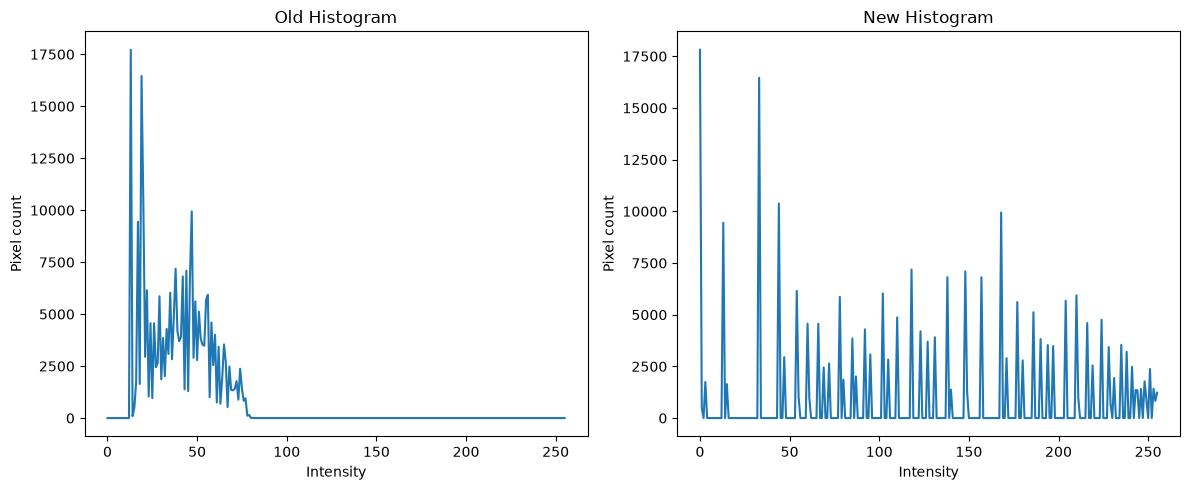

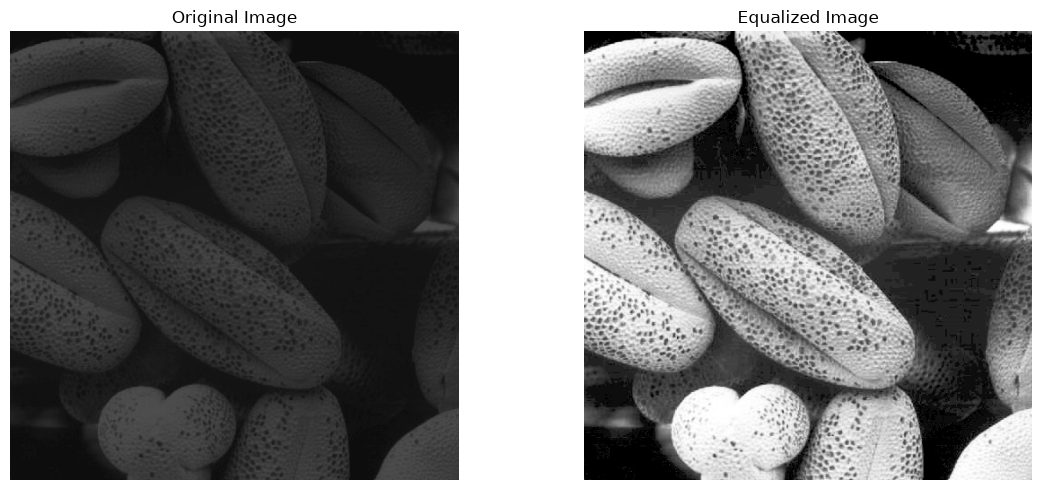

In [59]:
im = cv.imread("images/shells.tif", cv.IMREAD_GRAYSCALE)

old_hist = cv.calcHist([im], [0], None, [256], [0,256])

cdf = np.cumsum(old_hist)
cdf_min = cdf[cdf > 0].min()
lut = np.round((cdf-cdf_min) / (im.size-cdf_min) * 255).astype(np.uint8)
lut = np.clip(lut, 0, 255)

equalized_image = cv.LUT(im, lut)
new_hist = cv.calcHist([equalized_image], [0], None, [256], [0,256])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(old_hist)
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Old Histogram")

axes[1].plot(new_hist)
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("New Histogram")

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

axes2[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
axes2[0].axis('off')
axes2[0].set_title("Original Image")

axes2[1].imshow(cv.cvtColor(equalized_image, cv.COLOR_BGR2RGB))
axes2[1].axis('off')
axes2[1].set_title("Equalized Image")

plt.tight_layout()
plt.show()